# MiCRM Demo Notebook

Demonstrates parameter generation, matrix visualisation, community simulation,
richness calculation, effective Lotka-Volterra (eLV) approximation, and
invasion growth rates for the Microbial Consumer-Resource Model (MiCRM).

---

## 1. The Microbial Consumer-Resource Model (MiCRM)

\begin{align}
    \frac{dC_i}{dt} &= C_i \left( \sum_\alpha u_{i\alpha}(T)(1-\sum_\beta l^i_{\alpha\beta}) R_\alpha - m_i(T)\right),
    \\
    \frac{dR_\alpha}{dt} &= \rho_\alpha(R) - \sum_{i=1}^{N}\Bigl(C_i u_{i\alpha}(T)R_\alpha - \sum_{\beta=1}^{M}C_i u_{i\beta}(T)R_\beta l^i_{\beta\alpha}\Bigl).
\end{align}

| Symbol | Definition | Value | Units |
|---|---|---|---|
| $N$ | Consumer species | $15$ | — |
| $M$ | Resource types | $15$ | — |
| $C_i$ | Consumer $i$ biomass | $0.1$ (initial) | mass |
| $R_\alpha$ | Resource $\alpha$ abundance | $1.0$ (initial) | mass |
| $u_{i\alpha}(T)$ | Uptake rate | Temperature-dependent | 1/(mass·time) |
| $m_i(T)$ | Maintenance cost | Temperature-dependent | 1/time |
| $l^i_{\alpha\beta}$ | Leakage fraction $\alpha\to\beta$ | $\sim 0.3$ per species | fraction |
| $\rho_\alpha$ | Resource supply | $1.0$ | mass/time |

## 2. Thermal Performance Curve (TPC)

Uptake and maintenance follow the modified Sharpe-Schoolfield equation:

\begin{equation}
    B(T) = \frac{B_0\,e^{\frac{-E}{k}\left(\frac{1}{T}-\frac{1}{T_r}\right)}}{1+\frac{E}{E_d-E}\,e^{\frac{E_d}{k}\left(\frac{1}{T_{pk}}-\frac{1}{T}\right)}}
\end{equation}

| Symbol | Definition | Value | Units |
|---|---|---|---|
| $B_0$ | Normalisation constant | Empirically sampled | 1/(mass·time) |
| $E$ | Activation energy | $E_u\approx0.81$, $E_m\approx0.57$ (mean) | eV |
| $k$ | Boltzmann constant | $8.62\times10^{-5}$ | eV/K |
| $T_r$ | Reference temperature | $283.15$\,K (10°C) | K |
| $E_d$ | Deactivation energy | $3.5$ | eV |
| $T_{pk}$ | Peak temperature | $\sim\mathcal{N}(308\,K,\,5)$ | K |
| $\rho_t$ | $B_0$–$E$ covariance | $[-0.35,\,-0.35]$ | — |

## 3. Setup

In [1]:
using Printf

# Adjust path to your Base directory
include(joinpath(@__DIR__, "Base/sim_frame.jl"));

## 4. Model and parameter settings

In [2]:
### Model parameters
N     = 15
M     = 15
tspan = (0.0, 2.5e10)
x0    = vcat(fill(0.1, N), fill(1.0, M))

### Temperature parameters
ρ_t = [-0.35 -0.35]
Tr  = 273.15 + 10
Ed  = 3.5

### Steady-state callback
condition(du, t, integrator) = norm(integrator(t, Val{1})) <= eps()
affect!(integrator)           = terminate!(integrator)
cb = DiscreteCallback(condition, affect!)

DiscreteCallback{typeof(condition), typeof(affect!), typeof(SciMLBase.INITIALIZE_DEFAULT), typeof(SciMLBase.FINALIZE_DEFAULT), Nothing, Tuple{}}(Main.condition, Main.affect!, SciMLBase.INITIALIZE_DEFAULT, SciMLBase.FINALIZE_DEFAULT, Bool[1, 1], nothing, (), true)

## 5. Generate parameters

Edit the values below and re-run to explore how each parameter shapes the matrices.

| Parameter | Effect |
|---|---|
| `T_C` | Temperature (°C) — scales uptake and maintenance via Sharpe-Schoolfield |
| `N_modules` | Number of resource guilds — more = narrower niches |
| `s_ratio` | Within-guild uptake boost — scalar or length-N Vector. High = specialist, low = generalist |
| `n_byproducts` | Leakage chain length per resource (Integer or UnitRange, max < M) |
| `s_ratio_l` | Ratio of chain-to-background leakage — scalar. High = directed, low = diffuse. 1 = fully random |
| `L` | Per-species total leakage rate ~ Normal(0.3, 0.04), clamped to (0.01, 0.99) |

In [3]:
# ┌─────────────────────────────────────────────────────┐
# │  ✏️  EDIT THESE VALUES then Shift+Enter to update  │
# └─────────────────────────────────────────────────────┘
N            = 15
M            = 15
T_C          = 15       # Temperature (°C)
N_modules    = 4        # Uptake guilds (1 – M)
s_ratio      = rand(20.0:100.0, N)   # per-species: low = generalist, high = specialist
n_byproducts = 2:3      # Leakage chain length (Integer or UnitRange, max < M)
s_ratio_l    = 15.0     # leakage chain boost (scalar only)
species_show = 1        # Which species leakage to show (1 – N)
seed         = 666
# ──────────────────────────────────────────────────────

Tr  = 10.0 + 273.15
Ed  = 3.5
ρ_t = [-0.35 -0.35]
L   = clamp.(rand(Normal(0.3, 0.04), N), 0.01, 0.99)  # per-species leakage rate

Random.seed!(seed)

p = generate_params(N, M;
    f_u = modular_uptake, f_l = modular_leakage,
    f_m = F_m, f_ρ = F_ρ, f_ω = F_ω, f_Kc = F_Kc,
    N_modules    = N_modules,
    s_ratio      = s_ratio,
    n_byproducts = n_byproducts,
    s_ratio_l    = s_ratio_l,
    L = L, T = Float64(T_C) + 273.15, ρ_t = ρ_t, Tr = Tr, Ed = Ed,
    input_type   = "constant",
    ω            = fill(0.0, M),
    Kc           = fill(5.0, M)
)

println("Guild assignment: ", p.guild_assign)

Guild assignment: [1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4]


## 6. Uptake matrix

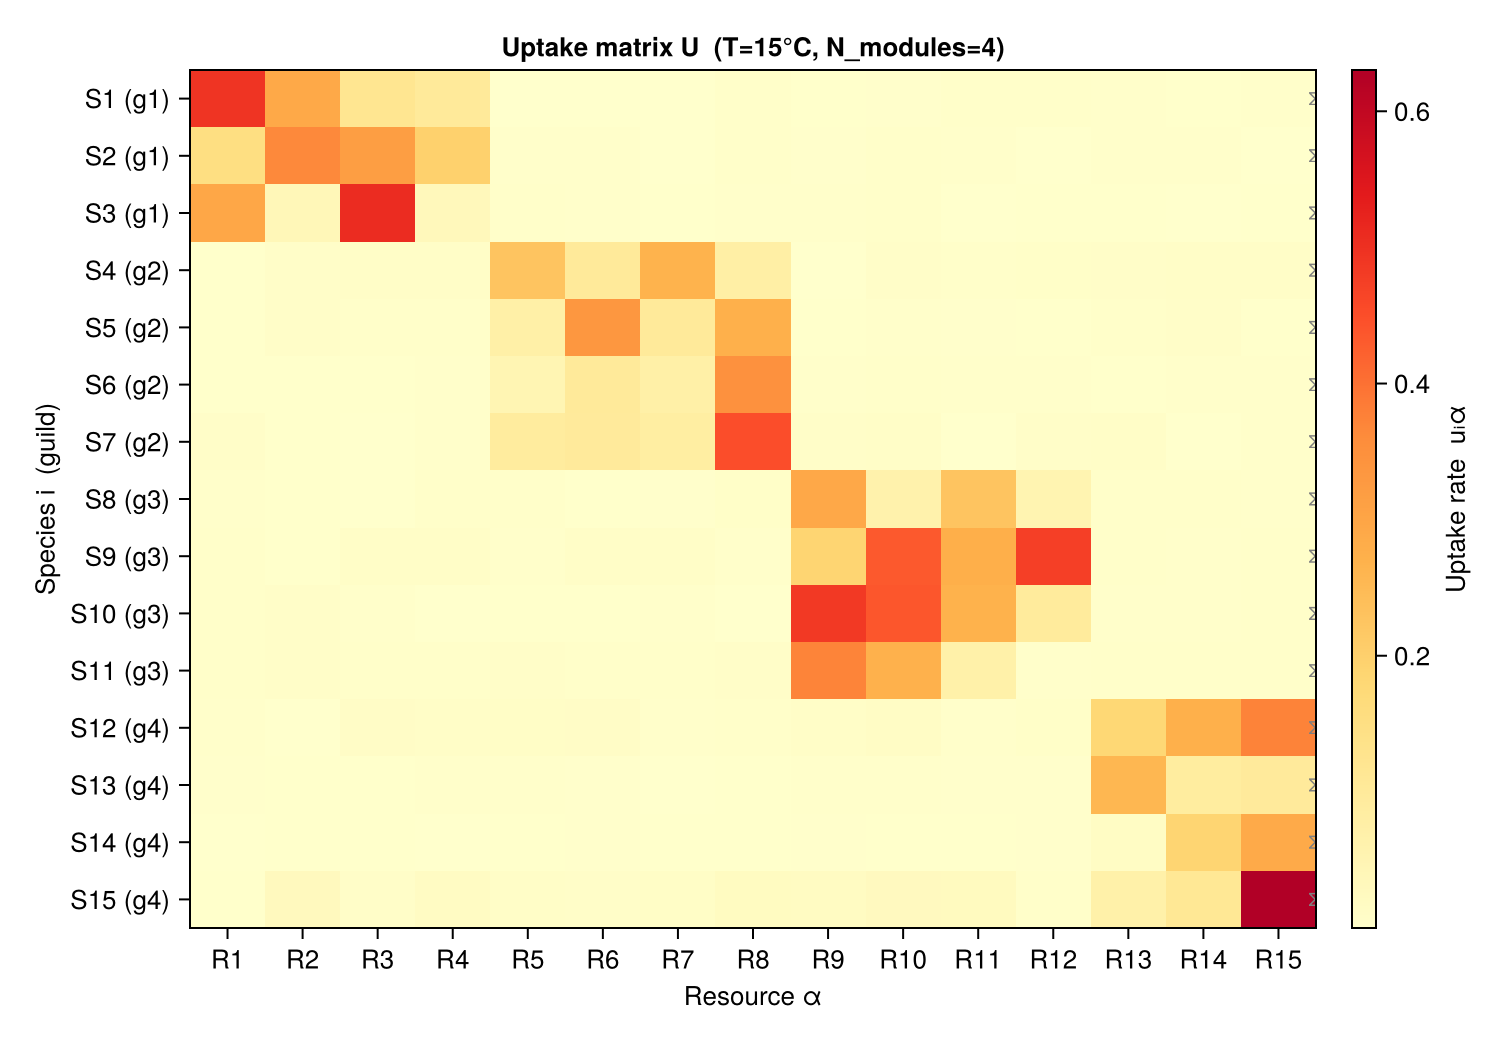

In [4]:
fig_u = Figure(size = (750, 520), fontsize = 13)

ax_u = Axis(fig_u[1, 1],
    title     = "Uptake matrix U  (T=$(T_C)°C, N_modules=$(N_modules))",
    xlabel    = "Resource α",
    ylabel    = "Species i  (guild)",
    xticks    = (1:M, ["R$α" for α in 1:M]),
    yticks    = (1:N, ["S$i (g$(p.guild_assign[i]))" for i in 1:N]),
    yreversed = true
)

hm_u = heatmap!(ax_u, 1:M, 1:N, p.u', colormap = :YlOrRd)
Colorbar(fig_u[1, 2], hm_u, label = "Uptake rate  uᵢα")

# annotate row sums
for i in 1:N
    text!(ax_u, M + 0.4, i;
        text     = @sprintf("Σ=%.3f", sum(p.u[i,:])),
        fontsize = 9,
        align    = (:left, :center),
        color    = :gray50)
end

fig_u

## 7. Leakage matrix (species level)

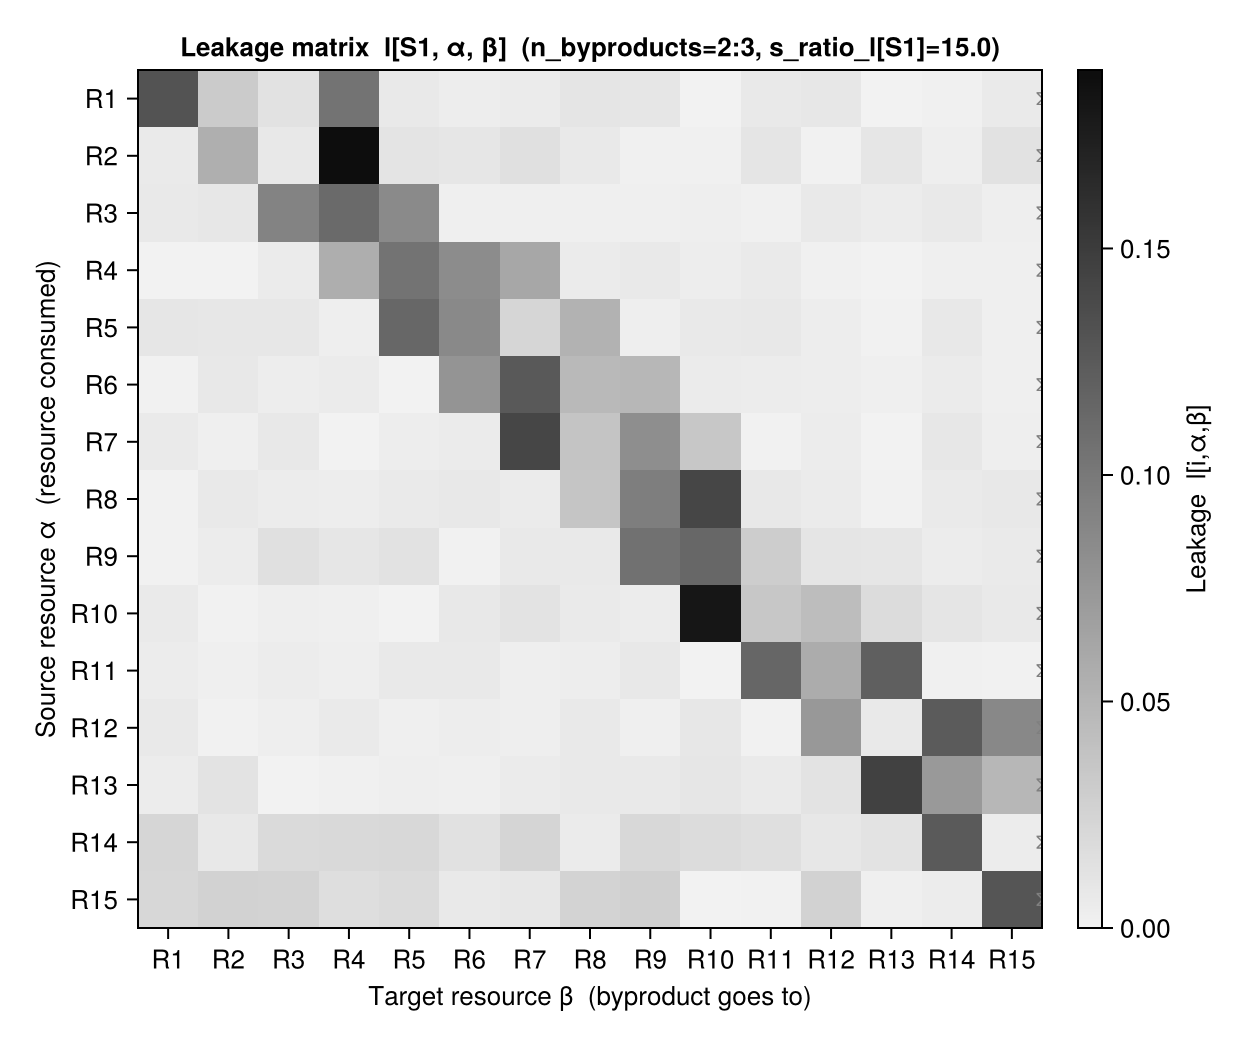

In [5]:
l_i = p.l[species_show, :, :]   # M × M leakage matrix for one species

fig_l = Figure(size = (620, 520), fontsize = 13)

ax_l = Axis(fig_l[1, 1],
    title     = "Leakage matrix  l[S$(species_show), α, β]  (n_byproducts=$(n_byproducts), s_ratio_l[S$(species_show)]=$(round(s_ratio_l[species_show], digits=1)))",
    xlabel    = "Target resource β  (byproduct goes to)",
    ylabel    = "Source resource α  (resource consumed)",
    xticks    = (1:M, ["R$β" for β in 1:M]),
    yticks    = (1:M, ["R$α" for α in 1:M]),
    yreversed = true
)

hm_l = heatmap!(ax_l, 1:M, 1:M, l_i',
    colormap   = Reverse(:grays),
    colorrange = (0, maximum(l_i) + 1e-10)
)
Colorbar(fig_l[1, 2], hm_l, label = "Leakage  l[i,α,β]")

# annotate row sums
for α in 1:M
    text!(ax_l, M + 0.4, α;
        text     = @sprintf("Σ=%.3f", sum(l_i[α,:])),
        fontsize = 9,
        align    = (:left, :center),
        color    = :gray50)
end

fig_l

## 8. Thermal performance curves

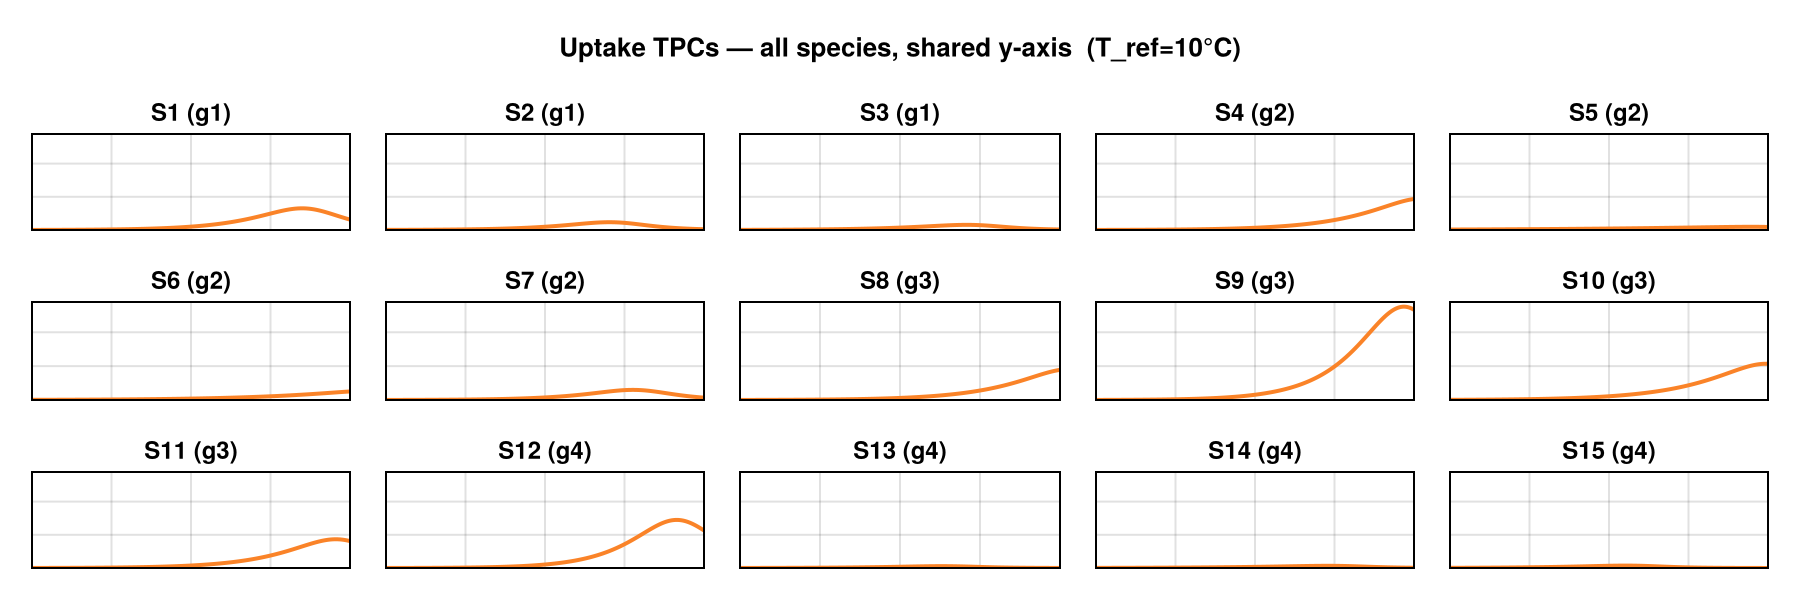

In [6]:
function sharpe_schoolfield(T_K, B0, E, Ed, Tp, Tr)
    k = 0.0000862
    B0 * exp((-E / k) * (1/T_K - 1/Tr)) /
        (1 + (E / (Ed - E)) * exp(Ed / k * (1/Tp - 1/T_K)))
end

temps_K  = range(273.15, 273.15 + 40, length = 200)
temps_C  = collect(temps_K) .- 273.15

u_curves = [max.(
    [sharpe_schoolfield(T_K, p.B[i,1], p.E[i,1], Ed, p.Tp[i,1], Tr) for T_K in temps_K],
    0.0) for i in 1:N]

u_ymax = maximum(maximum.(u_curves)) * 1.05

fig_tpc = Figure(size = (900, 300), fontsize = 12)
colors_tpc = cgrad(:tab20, N, categorical = true)

for i in 1:N
    row = (i - 1) ÷ 5 + 1
    col = (i - 1) % 5 + 1
    ax = Axis(fig_tpc[row, col],
        title  = "S$i (g$(p.guild_assign[i]))",
        limits = (0, 40, 0, u_ymax),
        xticksvisible = false, yticksvisible = false,
        xticklabelsvisible = false, yticklabelsvisible = false
    )
    lines!(ax, temps_C, u_curves[i], color = colorant"#FA8328", linewidth = 2)
end

Label(fig_tpc[0, :], "Uptake TPCs — all species, shared y-axis  (T_ref=$(Int(Tr - 273.15))°C)",
    fontsize = 13, font = :bold)

fig_tpc

## 9. Community simulation

In [7]:
prob = ODEProblem(dx!, x0, tspan, p)
sol  = solve(prob, AutoVern7(Rodas5()), save_everystep = true, callback = cb)

println("Simulation complete — $(length(sol.t)) time steps saved.")

Simulation complete — 58 time steps saved.


## 10. Consumer dynamics

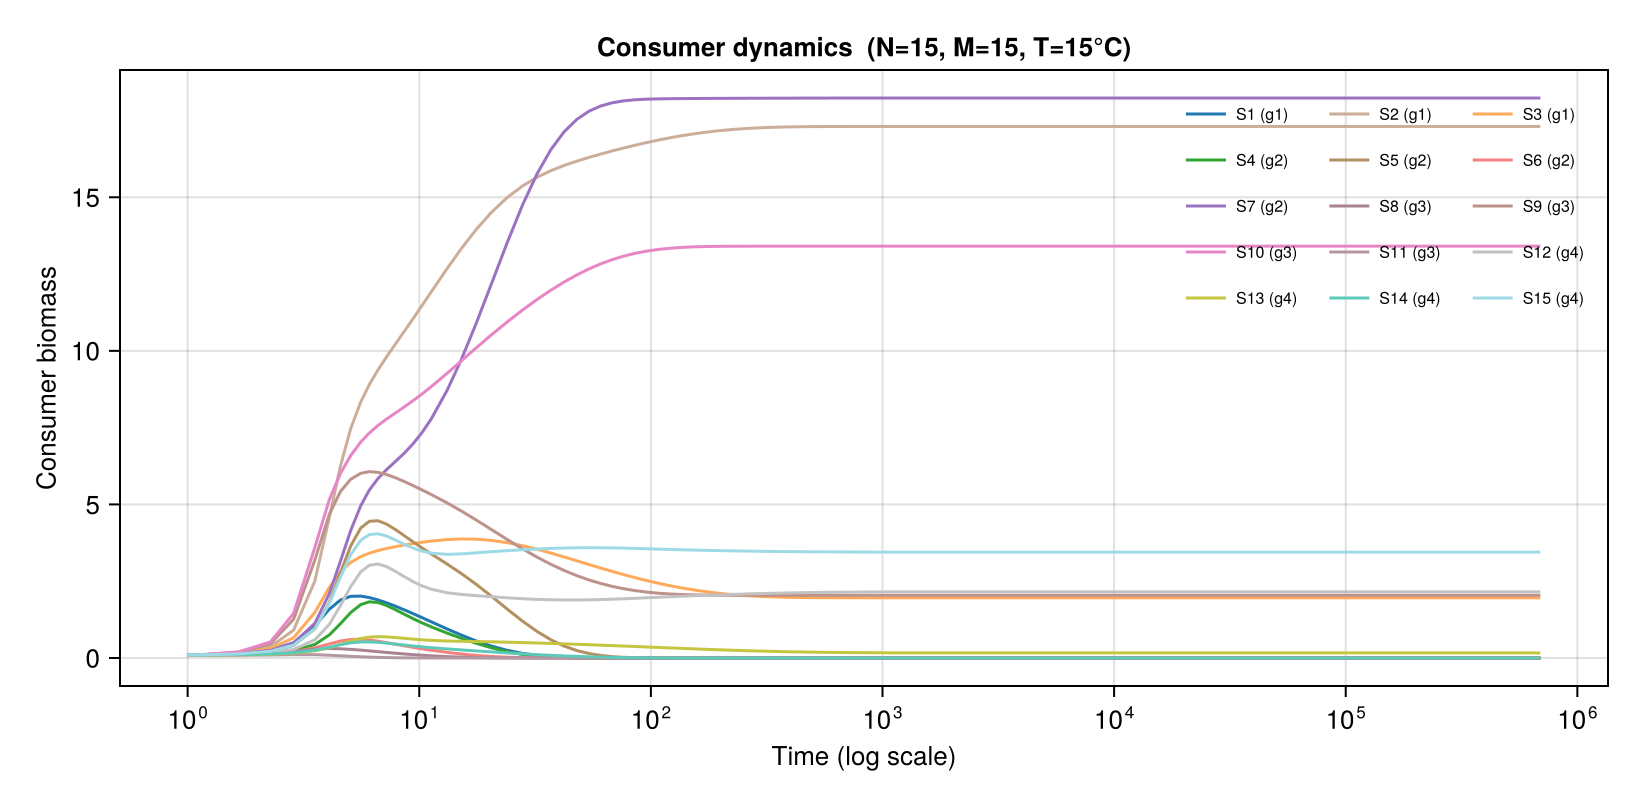

In [8]:
t_plot = sol.t .+ 1.0   # shift by 1 for log-scale

fig_c = Figure(size = (820, 400), fontsize = 13)
ax_c  = Axis(fig_c[1, 1],
    xlabel = "Time (log scale)",
    ylabel = "Consumer biomass",
    title  = "Consumer dynamics  (N=$(N), M=$(M), T=$(T_C)°C)",
    xscale = log10
)

cmap_c = cgrad(:tab20, N, categorical = true)
for i in 1:N
    bm = [u[i] for u in sol.u]
    lines!(ax_c, t_plot, bm, color = cmap_c[i], linewidth = 1.5,
           label = "S$i (g$(p.guild_assign[i]))")
end

axislegend(ax_c, position = :rt, nbanks = 3, labelsize = 8, framevisible = false)
fig_c

## 11. Resource dynamics

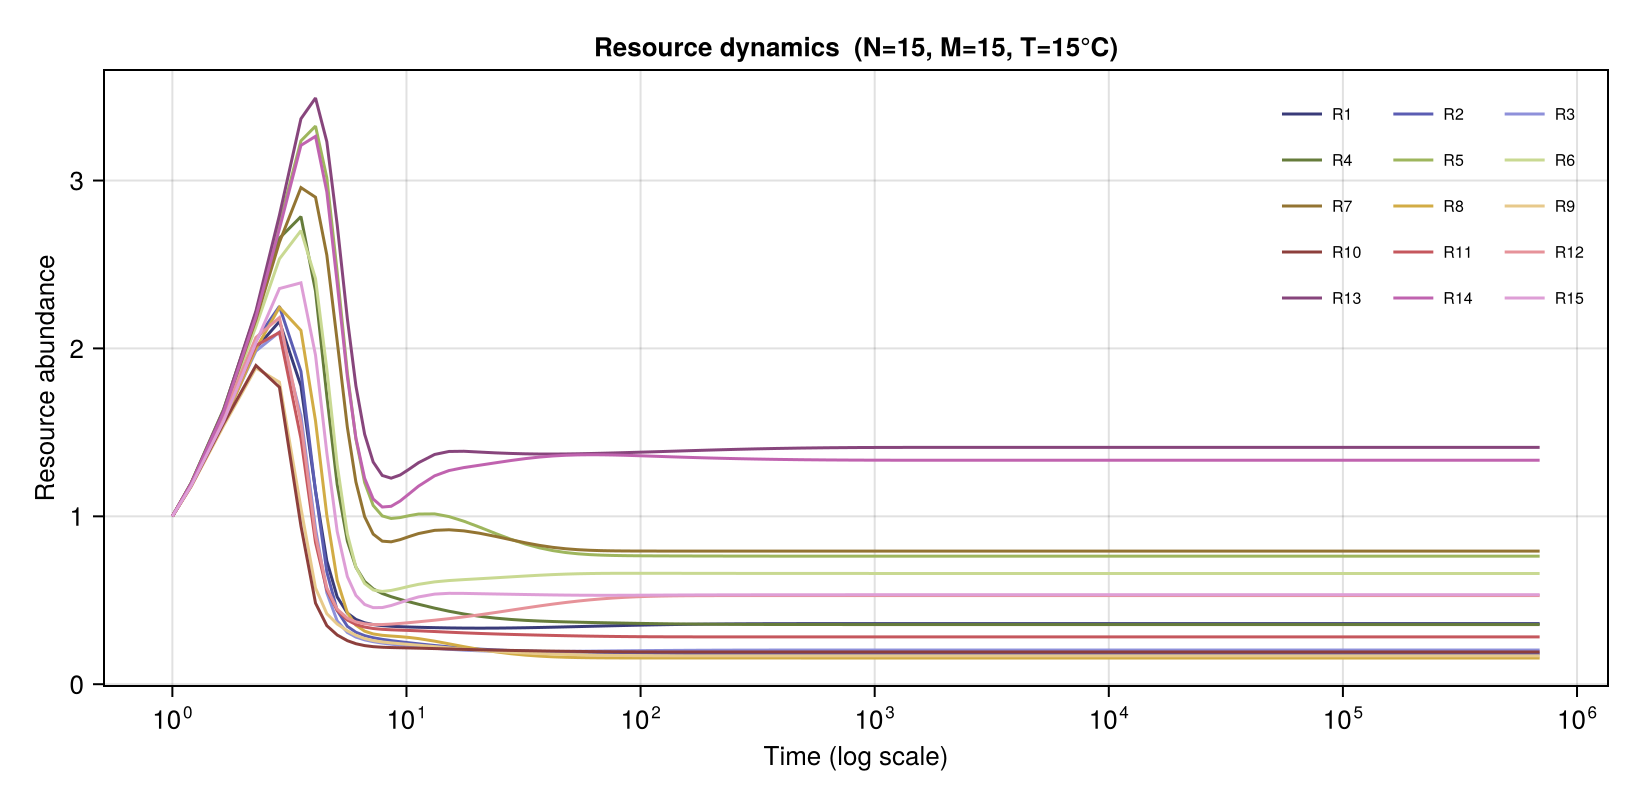

In [9]:
fig_r = Figure(size = (820, 400), fontsize = 13)
ax_r  = Axis(fig_r[1, 1],
    xlabel = "Time (log scale)",
    ylabel = "Resource abundance",
    title  = "Resource dynamics  (N=$(N), M=$(M), T=$(T_C)°C)",
    xscale = log10
)

cmap_r = cgrad(:tab20b, M, categorical = true)
for α in 1:M
    ra = [u[N + α] for u in sol.u]
    lines!(ax_r, t_plot, ra, color = cmap_r[α], linewidth = 1.5, label = "R$α")
end

axislegend(ax_r, position = :rt, nbanks = 3, labelsize = 8, framevisible = false)
fig_r

## 12. Community richness

Species with final biomass above the extinction threshold (10⁻⁷) are survivors.

In [10]:
extinction_threshold = 1e-7

bm_final  = sol.u[end][1:N]
survivors = findall(bm_final .> extinction_threshold)
extinct   = findall(bm_final .<= extinction_threshold)
richness  = length(survivors)

println("Final biomasses:")
for i in 1:N
    status = bm_final[i] > extinction_threshold ? "SURVIVE" : "extinct"
    @printf("  S%2d  guild %d:  %.2e  [%s]\n", i, p.guild_assign[i], bm_final[i], status)
end
println()
println("Richness:  $(richness) / $(N)")
println("Survivors: ", survivors)
println("Extinct:   ", extinct)

Final biomasses:
  S 1  guild 1:  7.61e-31  [extinct]
  S 2  guild 1:  1.73e+01  [SURVIVE]
  S 3  guild 1:  1.96e+00  [SURVIVE]
  S 4  guild 2:  -2.05e-31  [extinct]
  S 5  guild 2:  9.54e-31  [extinct]
  S 6  guild 2:  -2.98e-44  [extinct]
  S 7  guild 2:  1.82e+01  [SURVIVE]
  S 8  guild 3:  1.03e-47  [extinct]
  S 9  guild 3:  2.04e+00  [SURVIVE]
  S10  guild 3:  1.34e+01  [SURVIVE]
  S11  guild 3:  1.10e-63  [extinct]
  S12  guild 4:  2.15e+00  [SURVIVE]
  S13  guild 4:  1.66e-01  [SURVIVE]
  S14  guild 4:  9.71e-30  [extinct]
  S15  guild 4:  3.45e+00  [SURVIVE]

Richness:  8 / 15
Survivors: [2, 3, 7, 9, 10, 12, 13, 15]
Extinct:   [1, 4, 5, 6, 8, 11, 14]


## 13. Effective Lotka-Volterra (eLV) approximation

`LV_params()` derives the effective interaction matrix **A** and intrinsic
growth rates **r** for the surviving community via quasi-steady-state
approximation of resource dynamics (MacArthur 1970).

- Diagonal entries of **A** are species' self-regulation.
- Both diagonal and off-diagonal entries capture effective competition and facilitation mediated
  through shared resource use and cross-feeding.

In [11]:
lv  = LV_params(p = p, sol = sol)

# survivors already computed in Section 9
sur = findall(sol.u[end][1:N] .> 1e-7)
ns  = length(sur)

println("Survivors in eLV: ", sur)
println()
println("Intrinsic growth rates r:")
for i in 1:N
    status = i in sur ? "\e[1msurvivor\e[0m" : "extinct "
    @printf("  S%2d [%s]:  r = %+.4f\n", i, status, lv.r[i])
end
println()
println("Diagonal of A (self-regulation):")
for (k, i) in enumerate(1:N)
    status = i in sur ? "\e[1msurvivor\e[0m" : "extinct "
    @printf("  S%2d [%s]: A[%d,%d] = %.4f\n", i, status, i, i, lv.ℵ[i,i])
end

Survivors in eLV: [2, 3, 7, 9, 10, 12, 13, 15]

Intrinsic growth rates r:
  S 1 [extinct ]:  r = +0.0581
  S 2 [survivor]:  r = +0.1736
  S 3 [survivor]:  r = +0.1642
  S 4 [extinct ]:  r = +0.1933
  S 5 [extinct ]:  r = +0.2599
  S 6 [extinct ]:  r = -0.0441
  S 7 [survivor]:  r = +0.2269
  S 8 [extinct ]:  r = -0.1594
  S 9 [survivor]:  r = +0.2295
  S10 [survivor]:  r = +0.1419
  S11 [extinct ]:  r = -0.6110
  S12 [survivor]:  r = +0.6191
  S13 [survivor]:  r = +0.4376
  S14 [extinct ]:  r = +0.2657
  S15 [survivor]:  r = +0.4345

Diagonal of A (self-regulation):
  S 1 [extinct ]: A[1,1] = -0.0133
  S 2 [survivor]: A[2,2] = -0.0065
  S 3 [survivor]: A[3,3] = -0.0095
  S 4 [extinct ]: A[4,4] = -0.0416
  S 5 [extinct ]: A[5,5] = -0.0332
  S 6 [extinct ]: A[6,6] = -0.0052
  S 7 [survivor]: A[7,7] = -0.0100
  S 8 [extinct ]: A[8,8] = -0.0013
  S 9 [survivor]: A[9,9] = -0.0204
  S10 [survivor]: A[10,10] = -0.0052
  S11 [extinct ]: A[11,11] = -0.0005
  S12 [survivor]: A[12,12] = -0.1045
 

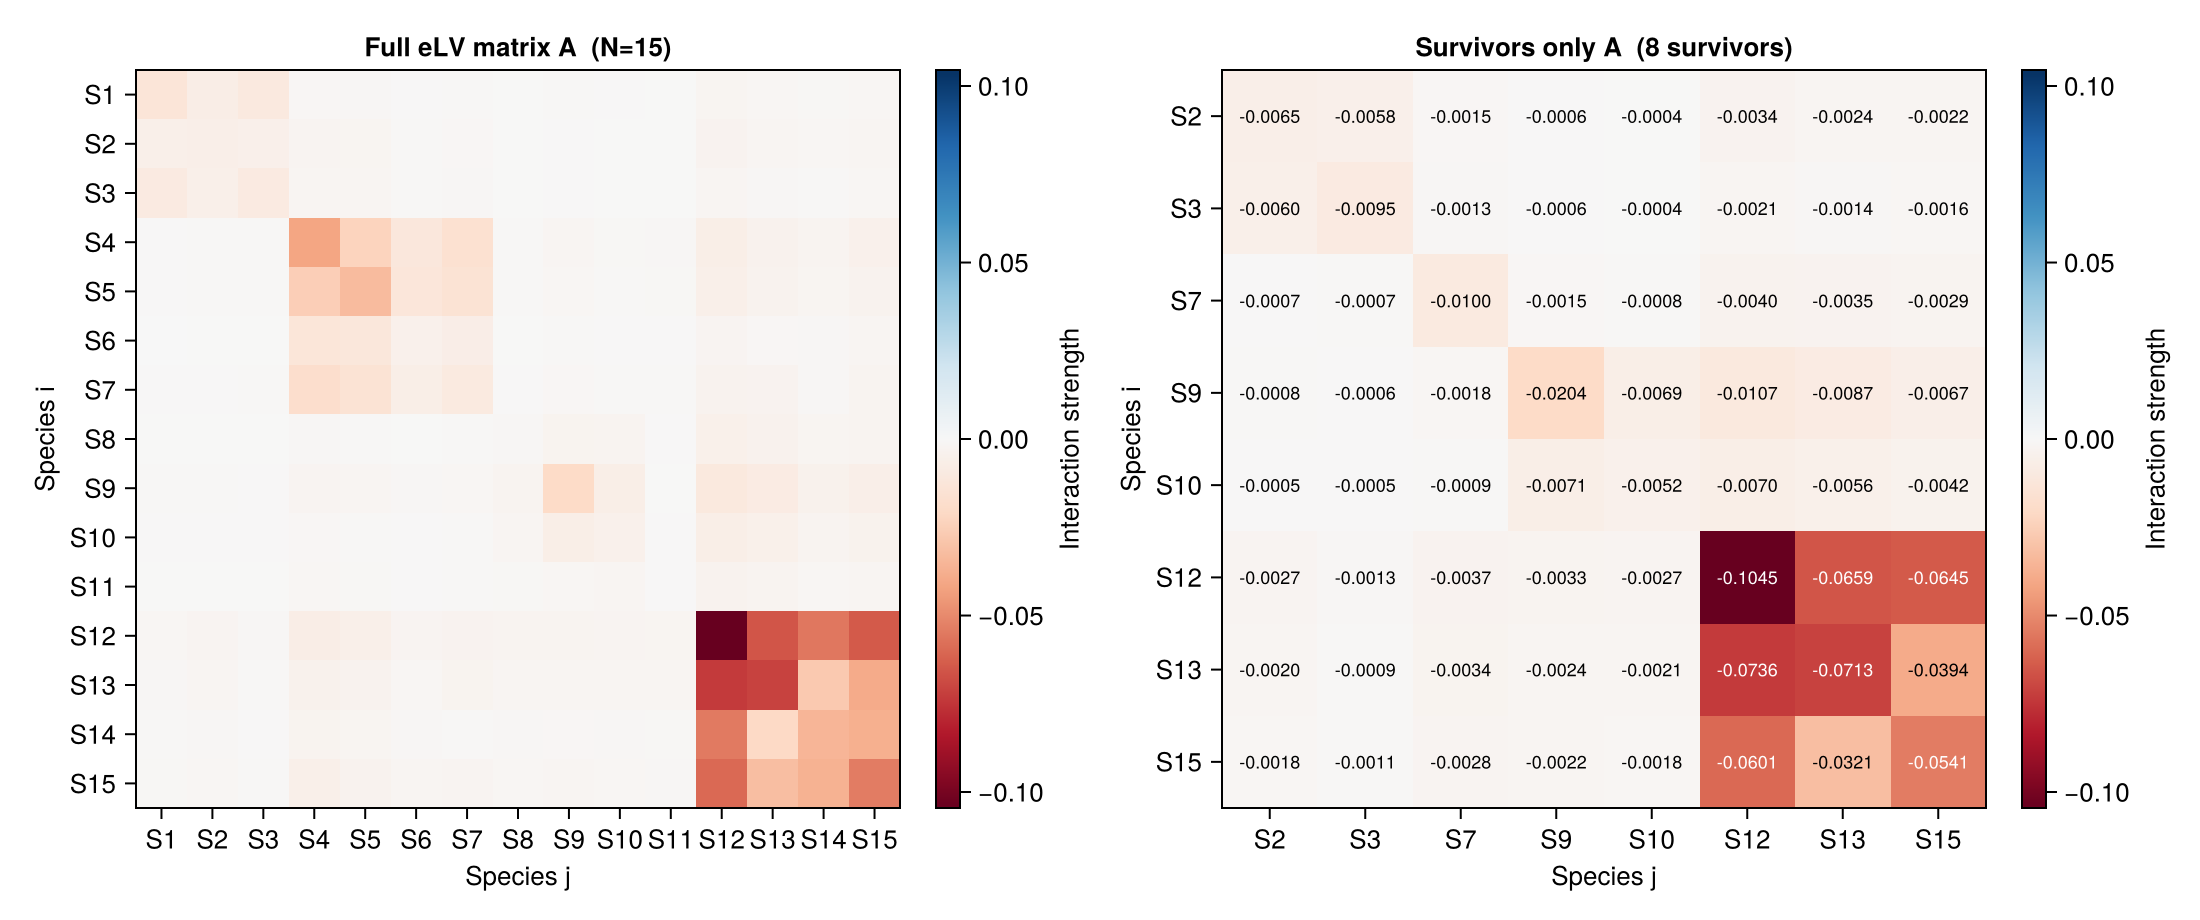

In [12]:
# ── eLV interaction matrix: full (left) and survivors-only (right) ──────────
ℵ_sur = lv.ℵ[sur, sur]   # ns × ns survivor submatrix
n_all = lv.N              # full N × N matrix

vlim_all = maximum(abs.(lv.ℵ))
vlim_sur = maximum(abs.(ℵ_sur))

fig_lv = Figure(size = (1100, 460), fontsize = 13)

# ── Left: full N × N matrix ───────────────────────────────────────────────
ax_all = Axis(fig_lv[1, 1],
    title     = "Full eLV matrix A  (N=$(n_all))",
    xlabel    = "Species j", ylabel = "Species i",
    xticks    = (1:n_all, ["S$j" for j in 1:n_all]),
    yticks    = (1:n_all, ["S$i" for i in 1:n_all]),
    yreversed = true
)
hm_all = heatmap!(ax_all, 1:n_all, 1:n_all, lv.ℵ',
    colormap = :RdBu, colorrange = (-vlim_all, vlim_all))
Colorbar(fig_lv[1, 2], hm_all, label = "Interaction strength")

# ── Right: survivors-only submatrix ──────────────────────────────────────
ax_sur = Axis(fig_lv[1, 3],
    title     = "Survivors only A  ($(ns) survivors)",
    xlabel    = "Species j", ylabel = "Species i",
    xticks    = (1:ns, ["S$(sur[j])" for j in 1:ns]),
    yticks    = (1:ns, ["S$(sur[i])" for i in 1:ns]),
    yreversed = true
)
hm_sur = heatmap!(ax_sur, 1:ns, 1:ns, ℵ_sur',
    colormap = :RdBu, colorrange = (-vlim_sur, vlim_sur))
Colorbar(fig_lv[1, 4], hm_sur, label = "Interaction strength")

for i in 1:ns, j in 1:ns
    text!(ax_sur, j, i;
        text     = @sprintf("%.4f", ℵ_sur[i,j]),
        fontsize = 9, align = (:center, :center),
        color    = abs(ℵ_sur[i,j]) > 0.5 * vlim_sur ? :white : :black)
end

fig_lv

## 14. Invasion growth rates

`invasion_growth_rate(i, p, x0, tspan, cb)` removes species *i*, runs the
resident community to equilibrium, then evaluates species *i*'s per-capita
growth rate in the resulting resource environment.

- **$r_{inv} > 0$**: can invade (would persist if introduced from rare)
- **$r_{inv} \leq 0$**: excluded by residents

In [13]:
# reuse the same steady-state callback as the main simulation
# (DiscreteCallback with norm of derivative <= eps)

r_inv = zeros(N)
for i in 1:N
    r_inv[i] = invasion_growth_rate(i, p, x0, tspan, cb)
    outcome = r_inv[i] > 1e-6 ? "\e[1mcan invade\e[0m" : "excluded  "
    @printf("  S%2d  guild %d:  r_inv = %+.4f  [%s]\n",
            i, p.guild_assign[i], r_inv[i], outcome)
end

  S 1  guild 1:  r_inv = -0.1256  [excluded  ]
  S 2  guild 1:  r_inv = +0.2750  [can invade]
  S 3  guild 1:  r_inv = +0.0130  [can invade]
  S 4  guild 2:  r_inv = -0.1821  [excluded  ]
  S 5  guild 2:  r_inv = -0.0856  [excluded  ]
  S 6  guild 2:  r_inv = -0.2057  [excluded  ]
  S 7  guild 2:  r_inv = +0.1755  [can invade]
  S 8  guild 3:  r_inv = -0.2487  [excluded  ]
  S 9  guild 3:  r_inv = +0.0553  [can invade]
  S10  guild 3:  r_inv = +0.1615  [can invade]
  S11  guild 3:  r_inv = -0.6831  [excluded  ]
  S12  guild 4:  r_inv = +0.0482  [can invade]
  S13  guild 4:  r_inv = +0.0041  [can invade]
  S14  guild 4:  r_inv = -0.0495  [excluded  ]
  S15  guild 4:  r_inv = +0.1091  [can invade]


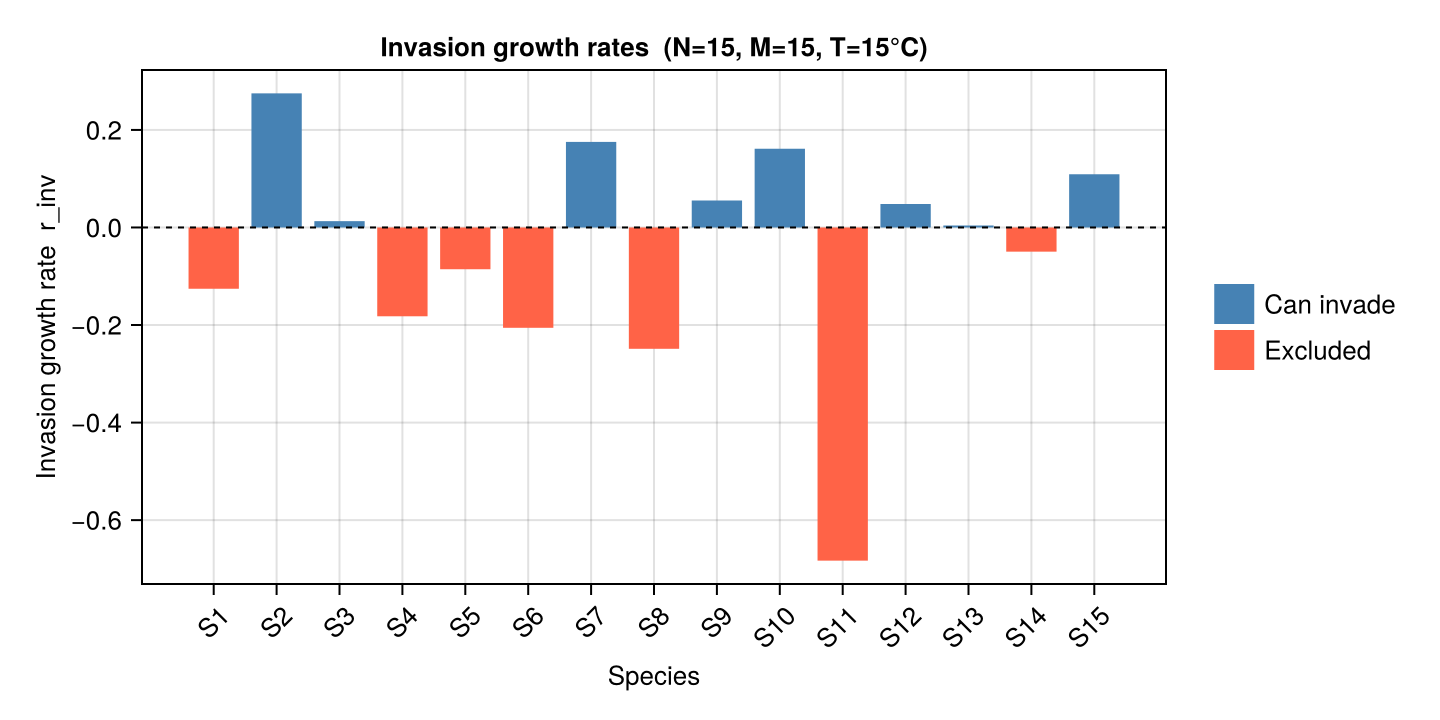

In [14]:
fig_inv = Figure(size = (720, 360), fontsize = 13)
ax_inv  = Axis(fig_inv[1, 1],
    xlabel = "Species",
    ylabel = "Invasion growth rate  r_inv",
    title  = "Invasion growth rates  (N=$(N), M=$(M), T=$(T_C)°C)",
    xticks = (1:N, ["S$i" for i in 1:N]),
    xticklabelrotation = π/4
)

bar_colors = [r_inv[i] > 1e-6  ? :steelblue :
              r_inv[i] < -1e-6 ? :tomato : :gray70 for i in 1:N]
barplot!(ax_inv, 1:N, r_inv, color = bar_colors)
hlines!(ax_inv, [0.0], color = :black, linewidth = 1, linestyle = :dash)

elem_s = PolyElement(color = :steelblue)
elem_e = PolyElement(color = :tomato)
Legend(fig_inv[1, 2], [elem_s, elem_e],
       ["Can invade", "Excluded"], framevisible = false)

fig_inv

## 15. Temperature comparison: 10°C vs 30°C

Simulate with the same seed at two temperatures. Consumer (top) and resource (bottom) dynamics are shown side by side.

In [15]:
Random.seed!(seed)
L_cmp = clamp.(rand(Normal(0.3, 0.04), N), 0.01, 0.99)

p10 = generate_params(N, M;
    f_u = modular_uptake, f_l = modular_leakage,
    f_m = F_m, f_ρ = F_ρ, f_ω = F_ω, f_Kc = F_Kc,
    N_modules = N_modules, s_ratio = s_ratio,
    n_byproducts = n_byproducts, s_ratio_l = s_ratio_l,
    L = L_cmp, T = 10.0 + 273.15, ρ_t = ρ_t, Tr = Tr, Ed = Ed,
    input_type = "constant", ω = fill(0.0, M), Kc = fill(5.0, M))
sol10 = solve(ODEProblem(dx!, x0, tspan, p10), AutoVern7(Rodas5()),
             save_everystep = true, callback = cb)

Random.seed!(seed)
p30 = generate_params(N, M;
    f_u = modular_uptake, f_l = modular_leakage,
    f_m = F_m, f_ρ = F_ρ, f_ω = F_ω, f_Kc = F_Kc,
    N_modules = N_modules, s_ratio = s_ratio,
    n_byproducts = n_byproducts, s_ratio_l = s_ratio_l,
    L = L_cmp, T = 30.0 + 273.15, ρ_t = ρ_t, Tr = Tr, Ed = Ed,
    input_type = "constant", ω = fill(0.0, M), Kc = fill(5.0, M))
sol30 = solve(ODEProblem(dx!, x0, tspan, p30), AutoVern7(Rodas5()),
             save_everystep = true, callback = cb)

sur10 = findall(sol10.u[end][1:N] .> 1e-7)
sur30 = findall(sol30.u[end][1:N] .> 1e-7)
println("Richness  10°C: ", length(sur10), "   30°C: ", length(sur30))

Richness  10°C: 5   30°C: 4


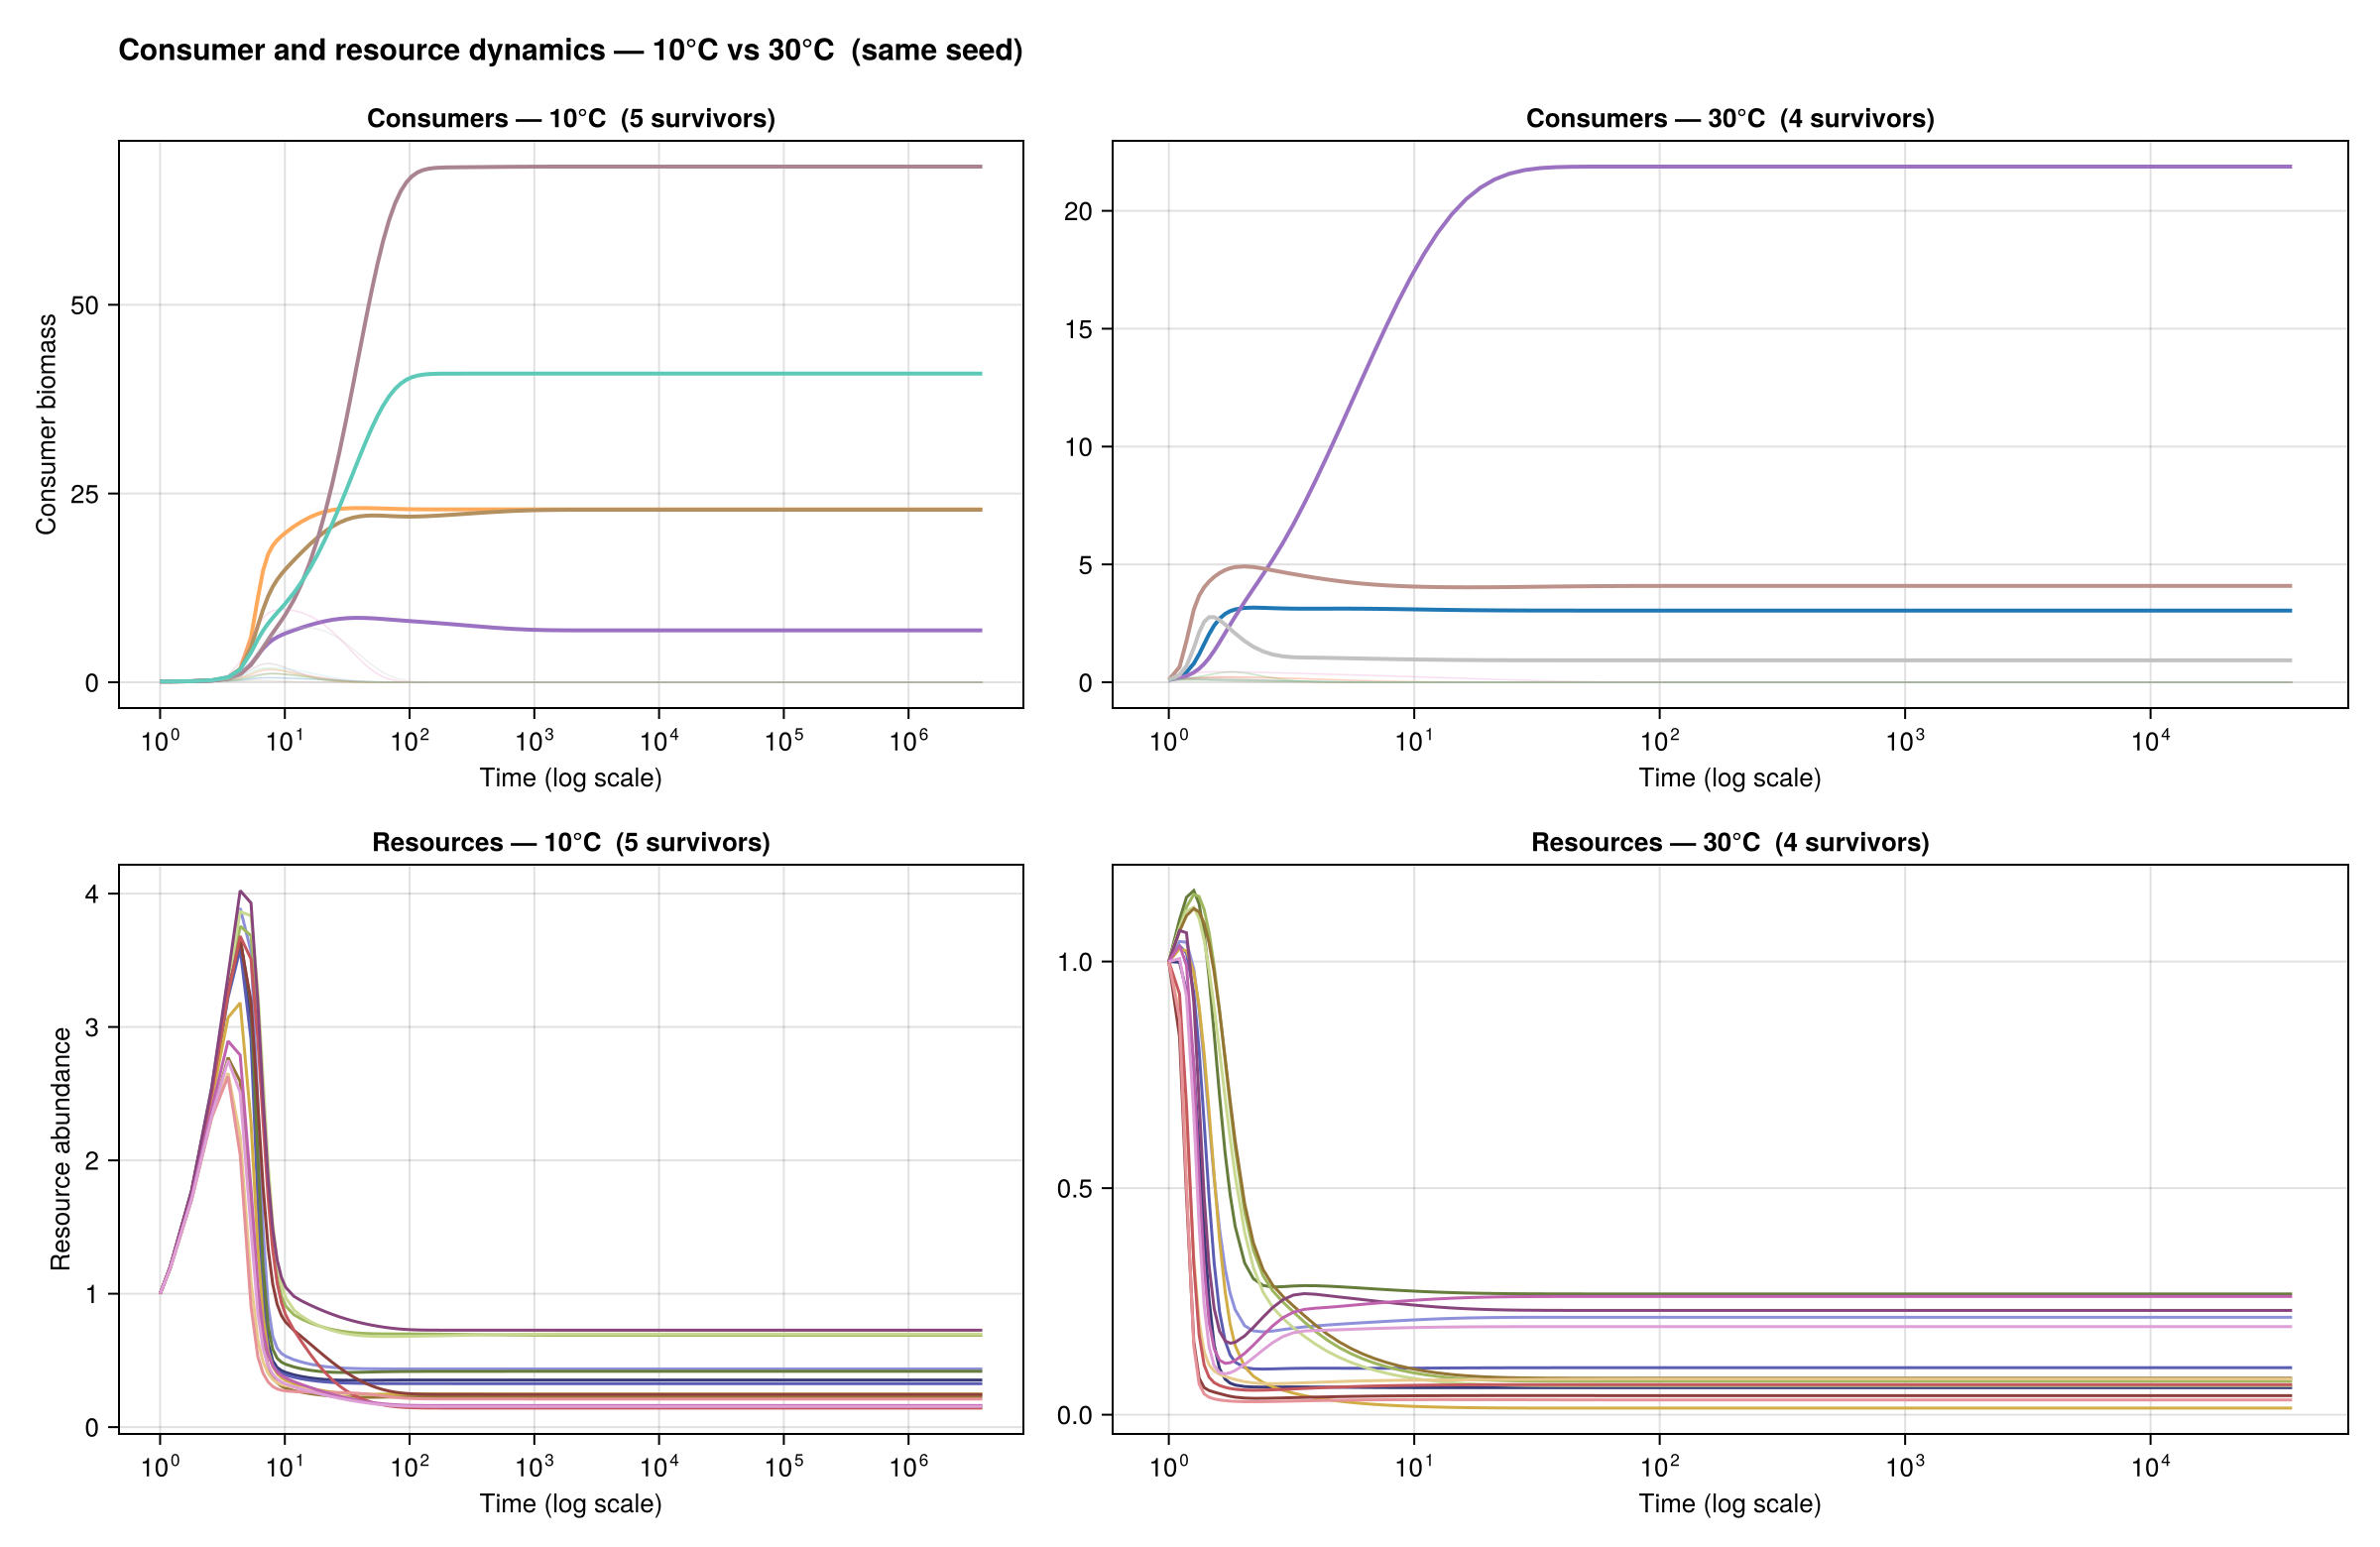

In [16]:
cmap_c = cgrad(:tab20,  N, categorical = true)
cmap_r = cgrad(:tab20b, M, categorical = true)
fig_cmp = Figure(size = (1200, 780), fontsize = 13)
Label(fig_cmp[0, :], "Consumer and resource dynamics — 10°C vs 30°C  (same seed)",
      fontsize = 15, font = :bold)
for (col, (sol_t, label, sur_t)) in enumerate([
        (sol10, "10°C  ($(length(sur10)) survivors)", sur10),
        (sol30, "30°C  ($(length(sur30)) survivors)", sur30)])
    t_plot = sol_t.t .+ 1.0
    ax_c = Axis(fig_cmp[1, col], title = "Consumers — $label",
        xlabel = "Time (log scale)",
        ylabel = col == 1 ? "Consumer biomass" : "", xscale = log10)
    for i in 1:N
        lines!(ax_c, t_plot, [u[i] for u in sol_t.u],
            color = (cmap_c[i], i in sur_t ? 1.0 : 0.25),
            linewidth = i in sur_t ? 2.0 : 0.8)
    end
    ax_r = Axis(fig_cmp[2, col], title = "Resources — $label",
        xlabel = "Time (log scale)",
        ylabel = col == 1 ? "Resource abundance" : "", xscale = log10)
    for α in 1:M
        lines!(ax_r, t_plot, [u[N+α] for u in sol_t.u],
            color = cmap_r[α], linewidth = 1.5)
    end
end
fig_cmp